## Experiment No: 8
## Experiment Title: Dependency Parsing and Sentence Analysis

**Name:** Himanshu Jadhav  
**Roll Number:** TE-32

### Step 1: Import Libraries

In [7]:
import spacy
import nltk
import pandas as pd
import matplotlib.pyplot as plt
from spacy import displacy
from IPython.display import display, HTML

nlp = spacy.load("en_core_web_sm")

print("spaCy model loaded successfully.")

spaCy model loaded successfully.


### Step 2: Sample Sentences (includes one ambiguous sentence)

In [8]:
sentences = [
    "The quick brown fox jumps over the lazy dog.",
    "She reads a book every night before sleeping.",
    "I saw the man with the telescope near the library.",
    "The teacher gave the students a difficult exam."
]

for i, sentence in enumerate(sentences, 1):
    print(f"{i}. {sentence}")

1. The quick brown fox jumps over the lazy dog.
2. She reads a book every night before sleeping.
3. I saw the man with the telescope near the library.
4. The teacher gave the students a difficult exam.


### Step 3: Dependency Parsing using spaCy

In [9]:
def dependency_table(sentence):
    doc  = nlp(sentence)
    rows = []
    for token in doc:
        rows.append({
            "Token"     : token.text,
            "Lemma"     : token.lemma_,
            "POS"       : token.pos_,
            "Tag"       : token.tag_,
            "Head"      : token.head.text,
            "Dependency": token.dep_,
            "Position"  : token.i
        })
    return pd.DataFrame(rows)

display(dependency_table(sentences[0]))

,Token,Lemma,POS,Tag,Head,Dependency,Position
0,The,the,DET,DT,fox,det,0
1,quick,quick,ADJ,JJ,fox,amod,1
2,brown,brown,ADJ,JJ,fox,amod,2
3,fox,fox,NOUN,NN,jumps,nsubj,3
4,jumps,jump,VERB,VBZ,jumps,ROOT,4
5,over,over,ADP,IN,jumps,prep,5
6,the,the,DET,DT,dog,det,6
7,lazy,lazy,ADJ,JJ,dog,amod,7
8,dog,dog,NOUN,NN,over,pobj,8
9,.,.,PUNCT,.,jumps,punct,9


## Step 4 — Visualize Dependency Trees


In [14]:
for i, sentence in enumerate(sentences, 1):
    doc = nlp(sentence)
    print(f"Sentence {i}: {sentence}")
    display(HTML(displacy.render(
        doc,
        style="dep",
        jupyter=False,
        options={
            "distance" : 100,
            "compact"  : True,
            "color"    : "#334155",
            "bg"       : "#ffffff",
            "font"     : "Source Sans Pro"
        }
    )))

Sentence 1: The quick brown fox jumps over the lazy dog.


Sentence 2: She reads a book every night before sleeping.


Sentence 3: I saw the man with the telescope near the library.


Sentence 4: The teacher gave the students a difficult exam.


## Step 5 — Identify Subject, Object, and Modifiers


In [15]:
def get_roles(sentence):
    doc = nlp(sentence)
    rows = []

    for token in doc:
        if token.dep_ in ("nsubj", "nsubjpass"):
            role = "Subject"
        elif token.dep_ in ("obj", "dobj", "pobj"):
            role = "Object"
        elif token.dep_ in ("amod", "advmod", "nmod"):
            role = "Modifier"
        else:
            continue

        rows.append({
            "Word": token.text,
            "Role": role,
            "Head": token.head.text,
            "Dependency": token.dep_
        })

    return pd.DataFrame(rows)

role_frames = []
for sentence in sentences:
    df_roles = get_roles(sentence)
    df_roles.insert(0, "Sentence", sentence)
    role_frames.append(df_roles)

roles_df = pd.concat(role_frames, ignore_index=True)
display(roles_df)

,Sentence,Word,Role,Head,Dependency
0,The quick brown fox jumps over the lazy dog.,quick,Modifier,fox,amod
1,The quick brown fox jumps over the lazy dog.,brown,Modifier,fox,amod
2,The quick brown fox jumps over the lazy dog.,fox,Subject,jumps,nsubj
3,The quick brown fox jumps over the lazy dog.,lazy,Modifier,dog,amod
4,The quick brown fox jumps over the lazy dog.,dog,Object,over,pobj
5,She reads a book every night before sleeping.,She,Subject,reads,nsubj
6,She reads a book every night before sleeping.,book,Object,reads,dobj
7,I saw the man with the telescope near the libr...,I,Subject,saw,nsubj
8,I saw the man with the telescope near the libr...,man,Object,saw,dobj
9,I saw the man with the telescope near the libr...,telescope,Object,with,pobj


## Step 6 — POS Tag and Dependency Relation Statistics


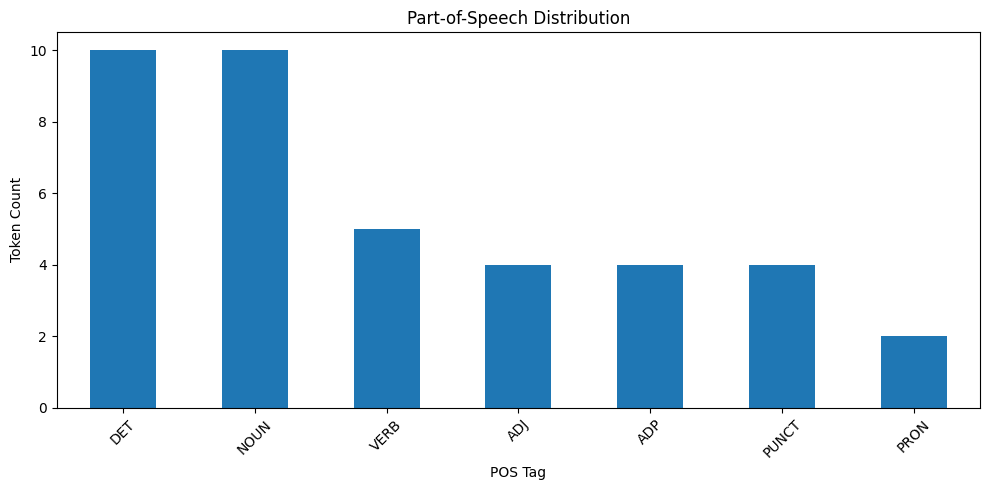

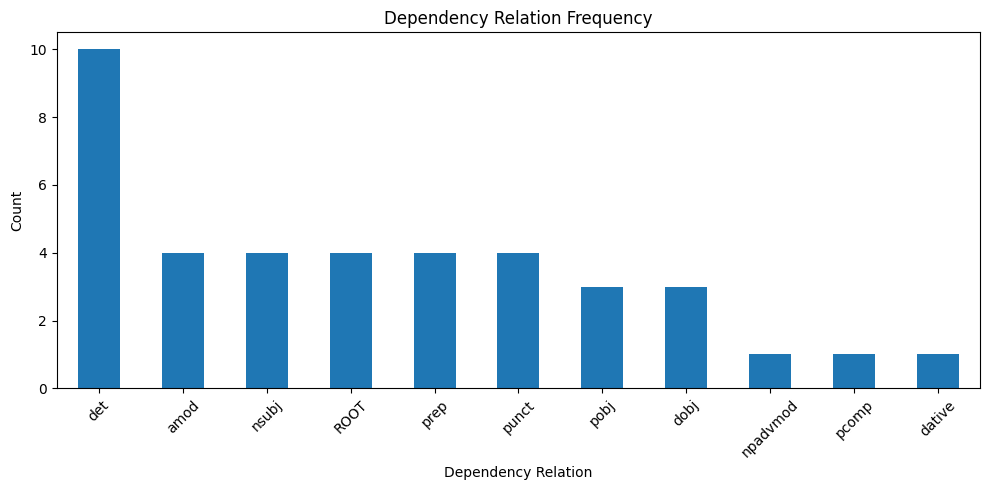

In [16]:
docs = [nlp(sentence) for sentence in sentences]

# POS distribution
pos_counts = pd.Series(
    [token.pos_ for doc in docs for token in doc]
).value_counts()

plt.figure(figsize=(10, 5))
pos_counts.plot(kind="bar")
plt.title("Part-of-Speech Distribution")
plt.xlabel("POS Tag")
plt.ylabel("Token Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Dependency relation distribution
dep_counts = pd.Series(
    [token.dep_ for doc in docs for token in doc]
).value_counts()

plt.figure(figsize=(10, 5))
dep_counts.plot(kind="bar")
plt.title("Dependency Relation Frequency")
plt.xlabel("Dependency Relation")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
# Summary table for the experiment
summary = pd.DataFrame({
    "Metric": [
        "Number of sentences",
        "Total tokens",
        "Unique POS tags",
        "Unique dependency relations"
    ],
    "Value": [
        len(docs),
        sum(len(doc) for doc in docs),
        len(pos_counts),
        len(dep_counts)
    ]
})

display(summary)

,Metric,Value
0,Number of sentences,4
1,Total tokens,39
2,Unique POS tags,7
3,Unique dependency relations,11


## Step 7 — Constituency-Style Parsing with NLTK Chunking


In [18]:
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("averaged_perceptron_tagger", quiet=True)
nltk.download("averaged_perceptron_tagger_eng", quiet=True)

from nltk import pos_tag, RegexpParser
from nltk.tokenize import word_tokenize

grammar = r'''
    NP: {<DT>?<JJ>*<NN.*>+}
'''

chunk_parser = RegexpParser(grammar)

for sentence in sentences[:2]:
    tokens = word_tokenize(sentence)
    tagged = pos_tag(tokens)
    tree = chunk_parser.parse(tagged)

    print("Sentence:", sentence)
    print("POS tags:", tagged)
    print("Chunk tree:")
    print(tree)
    print()


Sentence: The quick brown fox jumps over the lazy dog.
POS tags: [('The', 'DT'), ('quick', 'JJ'), ('brown', 'NN'), ('fox', 'NN'), ('jumps', 'VBZ'), ('over', 'IN'), ('the', 'DT'), ('lazy', 'JJ'), ('dog', 'NN'), ('.', '.')]
Chunk tree:
(S
  (NP The/DT quick/JJ brown/NN fox/NN)
  jumps/VBZ
  over/IN
  (NP the/DT lazy/JJ dog/NN)
  ./.)

Sentence: She reads a book every night before sleeping.
POS tags: [('She', 'PRP'), ('reads', 'VBZ'), ('a', 'DT'), ('book', 'NN'), ('every', 'DT'), ('night', 'NN'), ('before', 'IN'), ('sleeping', 'NN'), ('.', '.')]
Chunk tree:
(S
  She/PRP
  reads/VBZ
  (NP a/DT book/NN)
  (NP every/DT night/NN)
  before/IN
  (NP sleeping/NN)
  ./.)



## Step 8 — Analyze the Ambiguous Sentence


In [19]:
ambiguous_sentence = sentences[2]
doc_amb = nlp(ambiguous_sentence)

print("Ambiguous sentence:")
print(ambiguous_sentence)
print()

display(dependency_table(ambiguous_sentence))

print("Dependency visualization:")
display(HTML(displacy.render(
    doc_amb,
    style="dep",
    jupyter=False,
    options={"distance": 100, "compact": True}
)))


Ambiguous sentence:
I saw the man with the telescope near the library.



,Token,Lemma,POS,Tag,Head,Dependency,Position
0,I,I,PRON,PRP,saw,nsubj,0
1,saw,see,VERB,VBD,saw,ROOT,1
2,the,the,DET,DT,man,det,2
3,man,man,NOUN,NN,saw,dobj,3
4,with,with,ADP,IN,man,prep,4
5,the,the,DET,DT,telescope,det,5
6,telescope,telescope,NOUN,NN,with,pobj,6
7,near,near,ADP,IN,saw,prep,7
8,the,the,DET,DT,library,det,8
9,library,library,NOUN,NN,near,pobj,9


Dependency visualization:


## Step 9 — Final Interpretation

In [21]:
print("Experiment Completed Successfully")
print(f"Sentences analyzed    : {len(sentences)}")
print(f"Total tokens analyzed : {sum(len(doc) for doc in docs)}")
print(f"Ambiguous sentence    : {ambiguous_sentence}")

Experiment Completed Successfully
Sentences analyzed    : 4
Total tokens analyzed : 39
Ambiguous sentence    : I saw the man with the telescope near the library.
